First 5 Rows
              Booking No   Ticket Type  Ticket Count  Ticket Amount  \
0  EV1748739848135F6K005       Student             1           30.0   
1  EV1748758580099VGME5F        Adults             3          111.0   
2  EV1748763708930R7SJLB        Adults             1           37.0   
3  EV1748771174918ZLCXRL  Couple Entry             2           68.0   
4  EV17487734560106AU1PF        Adults             4          120.0   

   Processing Fee  Ticket Fee  Platform Fee  Agent Fee  Discount Amount  \
0            0.75         0.5             0          0              0.0   
1            2.78         1.5             0          0              0.0   
2            0.93         0.5             0          0              0.0   
3            1.70         1.0             0          0              0.0   
4            3.00         2.0             0          0              0.0   

   Grand Total  ... Booking Status  \
0        31.25  ...      confirmed   
1       115.28  ...      confirme

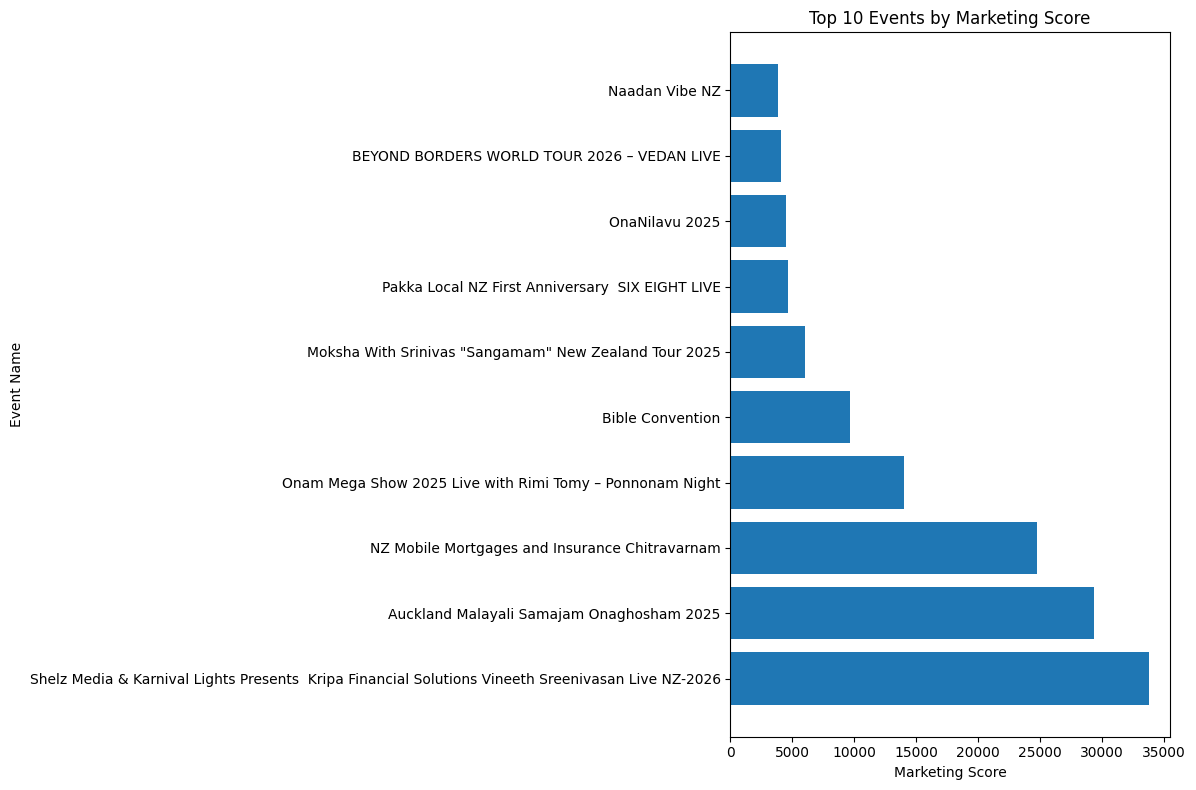


Top 10 Organizers
                                            Organizer  Organizer Revenue  \
4                   Karnival Lights and Shelz Media\n           83349.25   
7                                     NZ Mobile Group           80895.96   
1                           Auckland Malayali Samajam           77869.79   
2                                   Dadas New zealand           33061.80   
13        TARANAKI MALAYALEE ASSOCIATION INCORPORATED           19390.95   
9                                       PakkaLocal NZ           21228.10   
15                          United Rotorua Malayalees           13793.69   
6                           Moksha Base & Shelz Media           13751.00   
10  Radio Lemon Live New Zealand & Green Estate Di...            8548.85   
5                               Lost Monk Productions            8393.70   

    Ticket Count  Total Bookings  Refund Amount  Avg Revenue Per Booking  \
4           2104             780           0.00               106.85

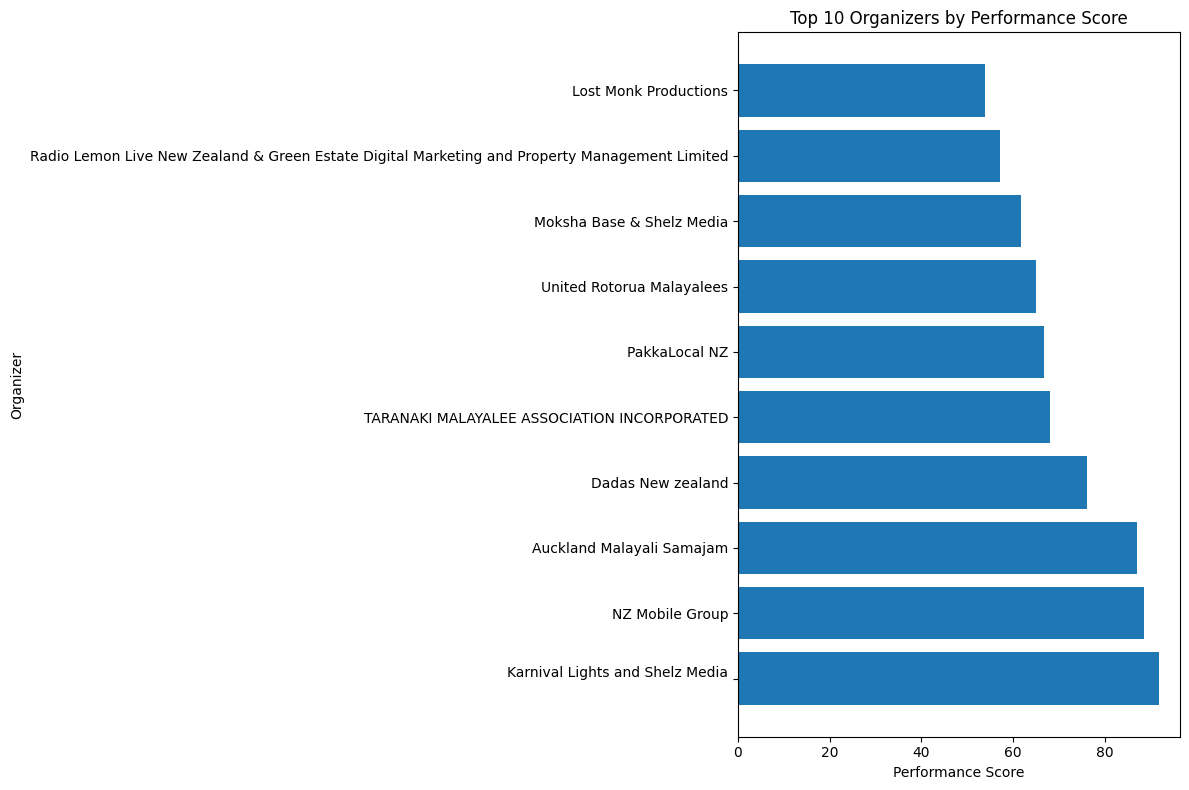

In [1]:
# ==========================================
# EVENTOX CASE STUDY
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Event_Booking_Details.csv")

# ==========================================
# EDA
# ==========================================

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# ==========================================
# DATA CLEANING
# ==========================================

numeric_cols = [
    'Ticket Count',
    'Ticket Amount',
    'Grand Total',
    'Processing Fee',
    'Platform Fee',
    'Stripe Revenue',
    'Eventox Revenue',
    'Organizer Revenue',
    'Refund Amount'
]

df[numeric_cols] = df[numeric_cols].fillna(0)

categorical_cols = [
    'Event Name',
    'Organizer',
    'Payment Status',
    'Booking Status'
]

df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# ==========================================
# DATE CONVERSION
# ==========================================

df['Created Date'] = pd.to_datetime(df['Created Date'])

# ==========================================
# FEATURE ENGINEERING
# ==========================================

df['Year'] = df['Created Date'].dt.year
df['Month'] = df['Created Date'].dt.month
df['Day'] = df['Created Date'].dt.day
df['Weekday'] = df['Created Date'].dt.day_name()

# Net Revenue
df['Net Revenue'] = df['Grand Total'] - df['Refund Amount']

# Revenue Per Ticket
df['Revenue Per Ticket'] = (
    df['Grand Total'] /
    df['Ticket Count'].replace(0, 1)
)

# Total Fees
df['Total Fees'] = (
    df['Processing Fee'] +
    df['Ticket Fee'] +
    df['Platform Fee'] +
    df['Agent Fee']
)

# Fee Percentage
df['Fee Percentage'] = (
    df['Total Fees'] /
    df['Grand Total'].replace(0, 1)
) * 100

# Refund Flag
df['Refund Flag'] = (
    df['Refund Amount'] > 0
).astype(int)

# Discount Used
df['Discount Used'] = (
    df['Discount Amount'] > 0
).astype(int)

# Booking Size
df["Booking Size"] = pd.cut(
    df["Ticket Count"],
    bins=[0, 2, 5, 10, 10000],
    labels=["Small", "Medium", "Large", "VIP"]
)

# Revenue Category
df["Revenue Category"] = pd.qcut(
    df["Grand Total"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# ==========================================
# SAVE CLEANED DATASET
# ==========================================

df.to_csv("eventox_cleaned.csv", index=False)

# ==========================================
# DATA DICTIONARY
# ==========================================

data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

data_dict.to_csv("data_dictionary.csv", index=False)

print("\nData Dictionary Saved Successfully")

# ==========================================
# USE CASE 4
# DYNAMIC MARKETING RECOMMENDATION ENGINE
# ==========================================

event_stats = df.groupby("Event Name").agg({
    "Ticket Count": "sum",
    "Grand Total": "sum",
    "Booking No": "count"
}).reset_index()

event_stats.rename(columns={
    "Booking No": "Total Bookings"
}, inplace=True)

# Marketing Score

event_stats["Marketing Score"] = (
      event_stats["Ticket Count"] * 0.4
    + event_stats["Grand Total"] * 0.4
    + event_stats["Total Bookings"] * 0.2
)

# Rank Events
event_stats = event_stats.sort_values(
    by="Marketing Score",
    ascending=False
)

# Priority Labels
event_stats["Priority"] = pd.qcut(
    event_stats["Marketing Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nTop 10 Events")
print(event_stats.head(10))

# Visualization

top10 = event_stats.head(10)

plt.figure(figsize=(12,8))
plt.barh(
    top10["Event Name"],
    top10["Marketing Score"]
)

plt.xlabel("Marketing Score")
plt.ylabel("Event Name")
plt.title("Top 10 Events by Marketing Score")
plt.tight_layout()
plt.show()

# ==========================================
# USE CASE 6
# ORGANIZER PERFORMANCE SCORING
# ==========================================

organizer_stats = df.groupby("Organizer").agg({
    "Organizer Revenue": "sum",
    "Ticket Count": "sum",
    "Booking No": "count",
    "Refund Amount": "sum"
}).reset_index()

organizer_stats.rename(columns={
    "Booking No": "Total Bookings"
}, inplace=True)

# KPI Calculations

organizer_stats["Avg Revenue Per Booking"] = (
    organizer_stats["Organizer Revenue"] /
    organizer_stats["Total Bookings"]
)

organizer_stats["Refund Rate"] = (
    organizer_stats["Refund Amount"] /
    organizer_stats["Organizer Revenue"]
) * 100

organizer_stats["Refund Rate"] = organizer_stats["Refund Rate"].fillna(0)

# Performance Score

organizer_stats["Score"] = (
      organizer_stats["Organizer Revenue"].rank(pct=True) * 40
    + organizer_stats["Total Bookings"].rank(pct=True) * 30
    + organizer_stats["Avg Revenue Per Booking"].rank(pct=True) * 20
    + (1 - organizer_stats["Refund Rate"].rank(pct=True)) * 10
)

organizer_stats["Score"] = organizer_stats["Score"].round(2)

# Ranking

organizer_stats = organizer_stats.sort_values(
    by="Score",
    ascending=False
)

print("\nTop 10 Organizers")
print(organizer_stats.head(10))

# Visualization

top_org = organizer_stats.head(10)

plt.figure(figsize=(12,8))
plt.barh(
    top_org["Organizer"],
    top_org["Score"]
)

plt.xlabel("Performance Score")
plt.ylabel("Organizer")
plt.title("Top 10 Organizers by Performance Score")
plt.tight_layout()
plt.show()